In [104]:
import numpy as np

# Shannon Entropy
def shannon_entropy(seq):
    values, counts = np.unique(seq, return_counts=True)
    prob = counts / len(seq)
    return -np.sum(prob * np.log2(prob + 1e-12))


# Partition
def partition(signal, num_bins):
    x = signal - np.min(signal)
    delta = (np.max(signal) - np.min(signal) + 1e-6) / num_bins
    sym = np.floor(x / delta).astype(int) + 1
    return sym


# FindPair2 
def find_pair2(sym_seq):
    M = int(np.max(sym_seq))
    count_array = np.zeros((M+1, M+1))

    L = len(sym_seq)
    i = 0

    while i < L - 1:
        a = int(sym_seq[i])
        b = int(sym_seq[i+1])
        count_array[a, b] += 1

        if a == b and i < L - 2 and sym_seq[i+2] == a:
            i += 1

        i += 1

    m = np.max(count_array)
    pos = np.argwhere(count_array == m)

    row = pos[:, 0]
    col = pos[:, 1]

    min_row = np.min(row)
    min_col = np.min(col)

    # MATLAB-style tie-breaking
    for r, c in zip(row, col):
        if r == min_row and c == min_col:
            return np.array([r, c])

    return pos[0]


# Substitute
def substitute(sym_seq, pair):
    new_seq = []
    rep_sym = int(np.max(sym_seq)) + 1

    i = 0
    L = len(sym_seq)

    while i < L - 1:
        if sym_seq[i] == pair[0] and sym_seq[i+1] == pair[1]:
            new_seq.append(rep_sym)
            i += 2
        else:
            new_seq.append(sym_seq[i])
            i += 1

    if i == L - 1:
        new_seq.append(sym_seq[-1])

    return np.array(new_seq), rep_sym


# FULL COMPRESSION SPECTRUM 
def compression_spectrum_scale_info_NEW(signal, num_bins):

    sym_seq = partition(signal, num_bins)
    Hnew = shannon_entropy(sym_seq)

    thresh = len(sym_seq)
    comp_log = np.zeros(thresh)

    # symbol → creation index mapping
    sym2idx = {}
    scale = []
    scale_comp = []

    # initialize original symbols
    for s in range(1, num_bins + 1):
        sym2idx[s] = len(scale)
        scale.append(1)

    sym_current = sym_seq.copy()
    N = 0
    length = len(sym_current)


    while Hnew > 1e-6 and len(sym_current) > 1 and N < thresh:

        pair = find_pair2(sym_current)
        sym_new, rep_sym = substitute(sym_current, pair)

        new_len = len(sym_new)
        if length == new_len + 1:
            break

        frac = length / new_len

        idx1 = sym2idx[int(pair[0])]
        idx2 = sym2idx[int(pair[1])]

        scale_val = scale[idx1] + scale[idx2]

        # register new symbol
        sym2idx[rep_sym] = len(scale)
        scale.append(scale_val)
        scale_comp.append([scale[idx1], scale[idx2]])


        comp_log[scale_val - 1] += np.log2(frac)

        # update
        sym_current = sym_new
        length = new_len
        Hnew = shannon_entropy(sym_current)
        N += 1

    comp_ratio = comp_log[:max(scale)]

    max_scale = max(scale)
    scale_comp_cell = [[] for _ in range(max_scale)]

    # only constructed symbols (after initial bins)
    for i, comp in enumerate(scale_comp):
        sc = scale[num_bins + i]
        scale_comp_cell[sc - 1].append(comp)

    Ent = np.zeros(max_scale)
    for i in range(max_scale):
        comps = scale_comp_cell[i]
        if len(comps) == 0:
            Ent[i] = 0
        else:
            comps = np.array(comps)
            if comps.ndim == 1:
                comps = comps.reshape(-1, 2)
            comps_sorted = np.sort(comps, axis=1)

            # unique rows
            ic = np.unique(comps_sorted, axis=0, return_inverse=True)[1]
            Ent[i] = shannon_entropy(ic + 1)

    return comp_ratio, N, scale, scale_comp_cell, Ent

In [105]:
from scipy.signal import firwin, filtfilt

def eegfilt_equivalent(signal, fs, lowcut, highcut):
    nyq = fs / 2
    taps = firwin(401, [lowcut/nyq, highcut/nyq], pass_zero=False)
    return filtfilt(taps, [1.0], signal)

In [106]:
import matplotlib.pyplot as plt

def plot_all(comp_ratio, scale, Ent):
    
    # Compression spectrum
    plt.figure(figsize=(8,4))
    plt.stem(range(1, len(comp_ratio)+1), comp_ratio)
    plt.xlabel("Scale")
    plt.ylabel("Log Compression Ratio")
    plt.title("Compression Spectrum")
    plt.grid()

    # Scale evolution
    plt.figure(figsize=(8,4))
    plt.step(range(len(scale)), scale)
    plt.xlabel("Iteration")
    plt.ylabel("Scale")
    plt.title("Scale Evolution")
    plt.grid()

    # Entropy of scale formation
    plt.figure(figsize=(8,4))
    plt.plot(Ent)
    plt.xlabel("Scale")
    plt.ylabel("Entropy")
    plt.title("Entropy of Scale Formation")
    plt.grid()

    plt.show()

In [107]:
def plot_compression_vs_scale(comp_ratio):
    scales = np.arange(1, len(comp_ratio) + 1)
    
    plt.figure(figsize=(8,4))
    plt.stem(scales, comp_ratio)
    plt.xlabel("Scale")
    plt.ylabel("Log Compression Ratio")
    plt.title("Compression Spectrum (Log Compression Ratio vs Scale)")
    plt.grid()

In [108]:
def plot_frequency_spectrum(signal, fs):
    from scipy.fft import fft, fftshift
    
    L = len(signal)
    
    # FFT
    Y = fft(signal)
    
    # Normalize
    Y = Y / L
    
    # Shift zero frequency to center
    Y_shifted = fftshift(Y)
    
    # Frequency axis
    f = np.linspace(-fs/2, fs/2, L)
    
    # Amplitude
    amplitude = np.abs(Y_shifted)
    
    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(f, amplitude)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title("Double-Sided Amplitude Spectrum")
    plt.grid()

In [109]:
def plot_entropy_vs_scale(Ent):
    scales = np.arange(1, len(Ent) + 1)
    
    plt.figure()
    plt.plot(scales, Ent, marker='o')
    plt.xlabel("Scale")
    plt.ylabel("Entropy")
    plt.title("Entropy of Scale Formation vs Scale")
    plt.grid()

In [110]:
def run_full_pipeline(file_path):

    X = np.loadtxt(file_path)

    fs = 173.61
    lowcut = 0.53
    highcut = 40

    # APPLY FILTER
    X_filt = eegfilt_equivalent(X, fs, lowcut, highcut)

    # TRIM
    X_filt = X_filt[50:-50]

    # COMPRESSION SPECTRUM
    print(len(compression_spectrum_scale_info_NEW(X_filt, 4)))
    comp_ratio, N, scale, scale_comp_cell, Ent = compression_spectrum_scale_info_NEW(X_filt, 4)

    print("ETC value:", N)
    print("Spectrum bandwidth:", np.count_nonzero(comp_ratio))
    print("Max scale:", max(scale))
    print("Mean fluctuation:", np.mean(np.abs(np.diff(scale))))

    # PLOTS
    plot_all(comp_ratio, scale, Ent)
    plot_frequency_spectrum(X_filt, fs)
    plot_compression_vs_scale(comp_ratio)
    plot_entropy_vs_scale(Ent)
    
    return comp_ratio, scale, Ent

5
ETC value: 93
Spectrum bandwidth: 31
Max scale: 42
Mean fluctuation: 7.583333333333333


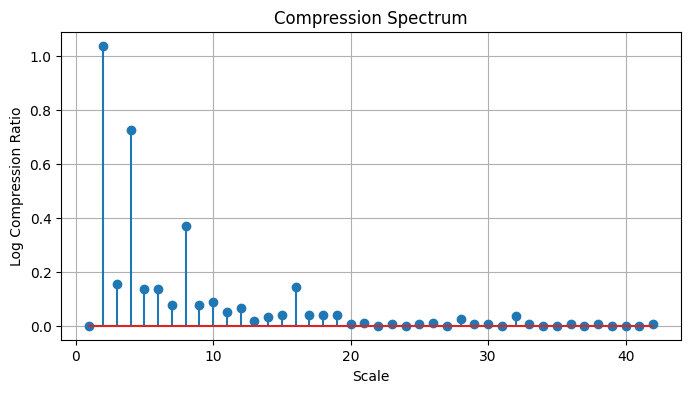

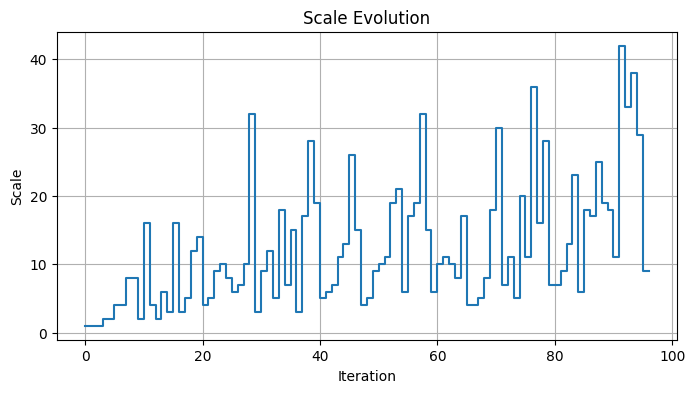

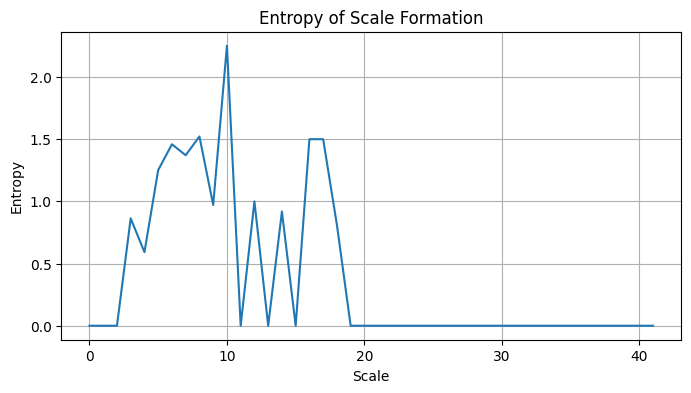

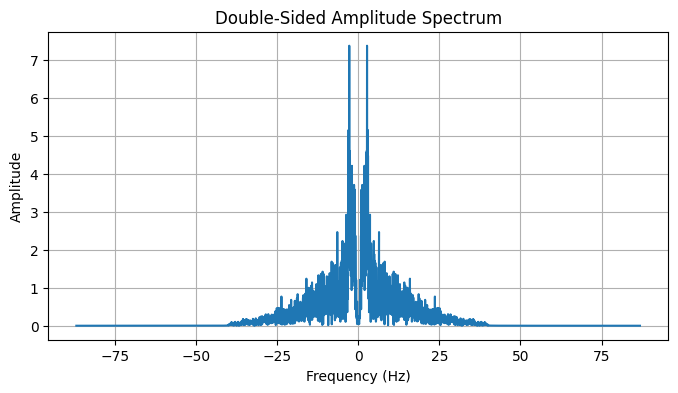

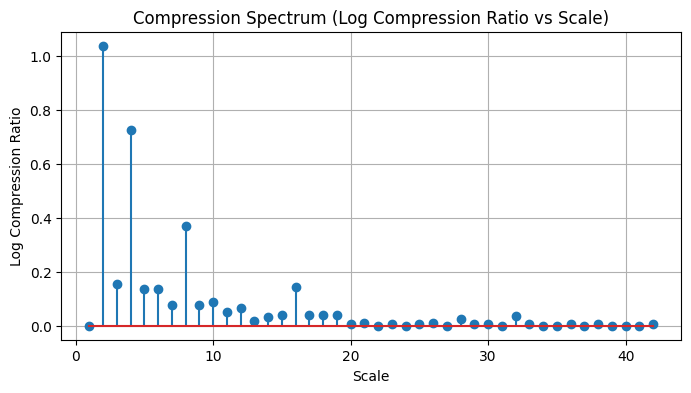

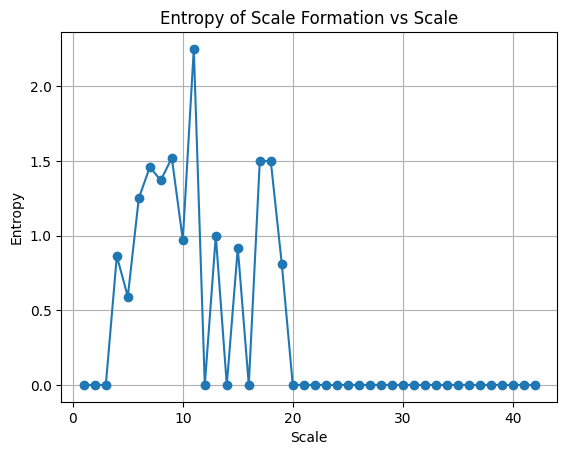

In [111]:
if __name__ == "__main__":
    run_full_pipeline("F056.txt")